In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import PIL
import requests
import os

In [20]:
# File paths
file_paths_red = [
    "../assignments/data/red_meat2022.xlsx",
    "../assignments/data/red_meat2023.xlsx",
    "../assignments/data/red_meat2024.xlsx"
]

# Read and concatenate red meat data
df_red_all = pd.concat([pd.read_excel(path).assign(Year=os.path.basename(path)[9:13]) for path in file_paths_red], ignore_index=True)

# Display first few rows of the combined DataFrame
df_red_all.head()

,"Red Meat Slaughtered In Provincially Inspected Plants, Ontario, January 01, 2022 to December 31, 2022 (# of head)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Year,"Red Meat Slaughtered In Provincially Inspected Plants, Ontario, January 01, 2023 to December 30, 2023 (# of head)","Red Meat Slaughtered In Provincially Inspected Plants, Ontario, January 01, 2024 to December 31, 2024 (# of head)",Unnamed: 14
0,NaN,January,February,March,April,May,June,July,August,September,October,November,December,YTD,022.,NaN,NaN,NaN
1,Bison,37,18,19,34,17,30,20,28,34,28,38,21,324,022.,NaN,NaN,NaN
2,Bulls,419,455,508,622,590,570,641,558,543,509,559,424,6398,022.,NaN,NaN,NaN
3,Cows,1103,1124,1090,915,886,1016,974,977,966,834,1013,866,11764,022.,NaN,NaN,NaN
4,Heifers,2156,2248,2749,2403,2385,2558,2302,2226,2487,2494,2866,2155,29029,022.,NaN,NaN,NaN


In [26]:
# Updated data loader to handle extra columns
def load_red_meat_data(path, year):
    df = pd.read_excel(path, skiprows=1)
    df = df.iloc[1:]  # skip second header
    df = df.iloc[:, :14]  # keep only first 14 columns
    df.columns = ['Animal', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'YTD']
    df = df.dropna(subset=['Animal'])
    df = df.set_index('Animal')
    df = df.drop(columns=['YTD'])
    df = df.transpose()
    df.index.name = 'Month'
    df.columns.name = 'Animal'
    df['Year'] = year
    return df.reset_index()
   
# Load and combine all three years
df_2022 = load_red_meat_data(file_paths_red[0], 2022)
df_2023 = load_red_meat_data(file_paths_red[1], 2023)
df_2024 = load_red_meat_data(file_paths_red[2], 2024)

df_red_all = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

# Display first few rows of the combined DataFrame
print(df_red_all.head())

Animal Month  Bulls  Cows  Heifers  Light Calves Female  Light Calves Male  \
0        Jan    419  1103     2156                   14                 26   
1        Feb    455  1124     2248                    3                 20   
2        Mar    508  1090     2749                    4                 13   
3        Apr    622   915     2403                    3                  8   
4        May    590   886     2385                    5                 47   

Animal  Steers  Veal Calves Female  Veal Calves Male  Water Buffalo  ...  \
0         3586                  49              2383             16  ...   
1         3340                  53              2463             33  ...   
2         4149                  75              2930             38  ...   
3         3595                  69              2602             18  ...   
4         3374                  46              2974             24  ...   

Animal  Pot-Bellied Pig  Ridgling  Sows  Stags  Wild Boars  \
0           

In [ ]:

# Convert to long format
df_red_long_all = df_red_all.melt(id_vars=['Month', 'Year'], var_name='Animal', value_name='Count')
df_red_long_all['Count'] = pd.to_numeric(df_red_long_all['Count'], errors='coerce')
df_red_long_all['Month'] = pd.Categorical(df_red_long_all['Month'], categories=month_order, ordered=True)

# Clean animal names: Remove Subtotal and the brackets
df_red_long_all['Animal'] = df_red_long_all['Animal'].str.replace(r"Subtotal\s*\((.*?)\)", r"\1", regex=True)

# Keep only selected animal subtotal categories (cleaned)
selected_animals = ['Bovine', 'Camelid', 'Caprine', 'Cervid', 'Ovine', 'Porcine', 'Ratite']
df_selected = df_red_long_all[df_red_long_all['Animal'].isin(selected_animals)]

# Group by month and animal, then pivot for stacked bar
df_monthly_totals = df_selected.groupby(['Month', 'Animal'], as_index=False)['Count'].sum()
df_pivot = df_monthly_totals.pivot(index='Month', columns='Animal', values='Count').fillna(0)
df_pivot = df_pivot.loc[month_order]  # Ensure month order


/var/folders/pj/71tll9d176q599rbrlfv5pvw0000gn/T/ipykernel_18282/2161984501.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_monthly_totals = df_selected.groupby(['Month', 'Animal'], as_index=False)['Count'].sum()


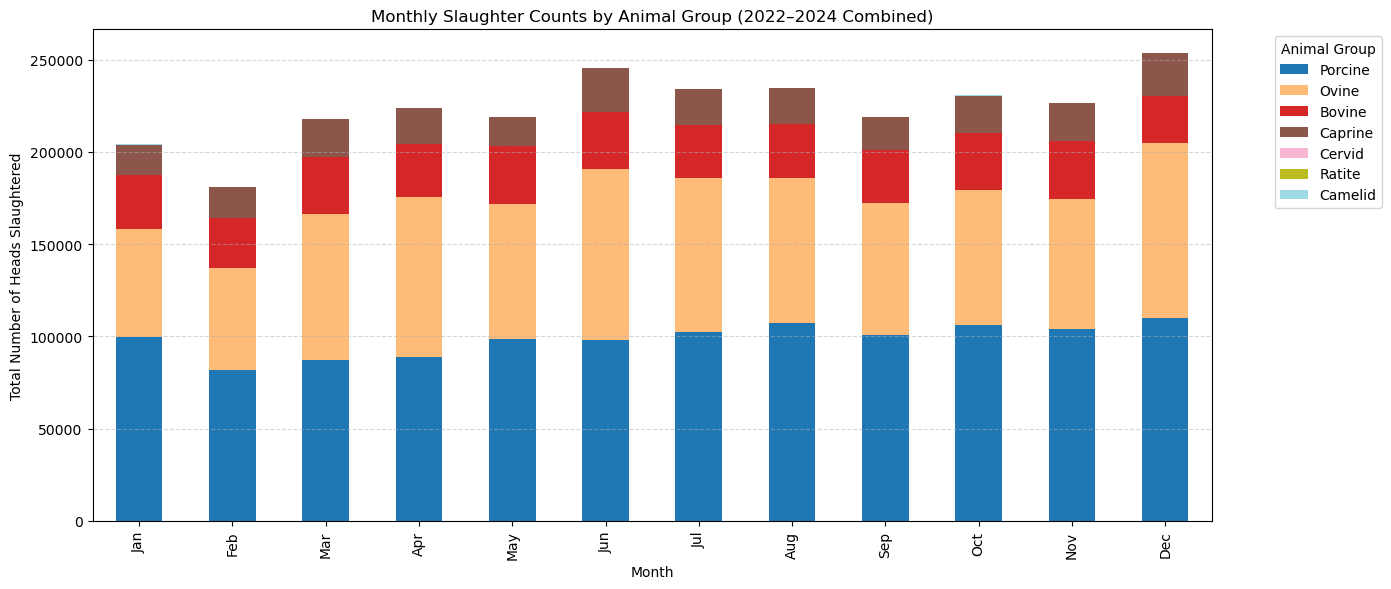

In [33]:
# Reorder columns so highest total is on the bottom of the stack
df_pivot = df_pivot[df_pivot.sum().sort_values(ascending=False).index]

# Plot the stacked bar chart
df_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='tab20'
)

plt.title("Monthly Slaughter Counts by Animal Group (2022–2024 Combined)")
plt.xlabel("Month")
plt.ylabel("Total Number of Heads Slaughtered")
plt.legend(title="Animal Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()